# 03 - 决策树与随机森林：用 if-else 学习规则

> 配套教程：`03_machine_learning/03_decision_tree.py`

决策树的直觉非常接近日常判断：不断问问题，把样本分到更明确的子组里。随机森林则把很多棵树组合起来，用投票降低单棵树的不稳定。

## 学习目标

| 能力 | 具体表现 |
|------|----------|
| 解释树结构 | 能说清楚根节点、内部节点、叶节点分别是什么 |
| 理解切分标准 | 能手算 Gini、Entropy 和信息增益 |
| 实现树模型 | 能用递归写出简单决策树 |
| 诊断过拟合 | 能解释为什么树太深容易记住噪声 |
| 理解随机森林 | 能说明 Bootstrap 和投票为什么有效 |

In [1]:
# 环境设置
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager


def configure_chinese_font():
    preferred_fonts = [
        "Noto Sans CJK SC", "Noto Sans CJK JP", "Source Han Sans SC",
        "WenQuanYi Zen Hei", "WenQuanYi Micro Hei", "SimHei",
        "Microsoft YaHei", "PingFang SC", "Arial Unicode MS",
    ]
    available_fonts = {font.name for font in font_manager.fontManager.ttflist}
    for font_name in preferred_fonts:
        if font_name in available_fonts:
            plt.rcParams["font.sans-serif"] = [font_name, "DejaVu Sans"]
            plt.rcParams["font.family"] = "sans-serif"
            print(f"Matplotlib 中文字体: {font_name}")
            return font_name
    print("未检测到可用中文字体，中文图表可能显示为方框。")
    print("Linux 可安装：sudo apt-get install fonts-noto-cjk 或 fonts-wqy-zenhei")
    return None


CHINESE_FONT = configure_chinese_font()
plt.rcParams["axes.unicode_minus"] = False
np.set_printoptions(precision=4, suppress=True)
np.random.seed(42)
print("环境准备完毕")

from collections import Counter
from sklearn.datasets import load_iris, make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

Matplotlib 中文字体: Noto Sans CJK JP
环境准备完毕


## 1. 决策树像一套自动学出来的问题清单

对鸢尾花分类，树可能学到类似规则：

```text
花瓣长度 <= 2.45 ?
├── 是：setosa
└── 否：花瓣宽度 <= 1.75 ?
    ├── 是：versicolor
    └── 否：virginica
```

训练决策树就是自动寻找这些问题。每个问题的形式通常是：

$$x_j \le t ?$$

其中 $x_j$ 是某个特征，$t$ 是阈值。

### 决策树和线性模型的思维差异

逻辑回归用一条直线或超平面把空间分开；决策树则用一系列横平竖直的切分把空间切成小区域。

这带来两个重要特点：

1. **可解释性强**：每条路径都是一串 if-else 规则，适合向非技术人员解释。
2. **容易过拟合**：如果允许无限切分，树可以把训练集切得非常碎，把噪声也记住。

决策树特别适合表格数据，尤其是特征有明显阈值含义的时候。例如：年龄是否大于 35、收入是否超过某个数、花瓣长度是否小于 2.45。

## 2. 什么叫节点“纯”

如果一个节点里全是同一类样本，它就是纯的；如果多类混在一起，它就不纯。

决策树每次切分都想让左右子节点更纯。常用不纯度指标：

**Gini impurity**：

$$Gini=1-\sum_i p_i^2$$

**Entropy**：

$$H=-\sum_i p_i\log_2(p_i)$$

这里 $p_i$ 是节点中第 $i$ 类样本比例。

In [2]:
def gini_impurity(y):
    if len(y) == 0:
        return 0
    counts = Counter(y)
    probs = [count / len(y) for count in counts.values()]
    return 1 - sum(p ** 2 for p in probs)


def entropy(y):
    if len(y) == 0:
        return 0
    counts = Counter(y)
    probs = [count / len(y) for count in counts.values()]
    return -sum(p * np.log2(p) for p in probs if p > 0)


examples = {
    "全是 A": [0, 0, 0, 0],
    "3 个 A + 1 个 B": [0, 0, 0, 1],
    "2 个 A + 2 个 B": [0, 0, 1, 1],
    "三类混合": [0, 1, 2, 2],
}

print(f"{'节点样本':<18} {'Gini':>8} {'Entropy':>10}")
print("-" * 40)
for name, labels in examples.items():
    print(f"{name:<18} {gini_impurity(labels):>8.4f} {entropy(labels):>10.4f}")

节点样本                   Gini    Entropy
----------------------------------------
全是 A                 0.0000    -0.0000
3 个 A + 1 个 B        0.3750     0.8113
2 个 A + 2 个 B        0.5000     1.0000
三类混合                 0.6250     1.5000


## 3. 信息增益：切分到底好不好

一个切分是否好，要看切分后不纯度减少了多少：

$$Gain=I(parent)-\left(\frac{n_L}{n}I(left)+\frac{n_R}{n}I(right)\right)$$

- $I(parent)$：父节点不纯度。
- $I(left)$、$I(right)$：左右子节点不纯度。
- $\frac{n_L}{n}$、$\frac{n_R}{n}$：左右子节点样本占比。

信息增益越大，表示切分越能让数据变纯。

In [3]:
y_parent = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])
candidate_splits = {
    "一般切分": (np.array([0, 0, 0, 0, 1]), np.array([0, 1, 1, 1, 1])),
    "完美切分": (np.array([0, 0, 0, 0, 0]), np.array([1, 1, 1, 1, 1])),
}

parent_entropy = entropy(y_parent)
print(f"父节点 entropy = {parent_entropy:.4f}")
for name, (left, right) in candidate_splits.items():
    weighted = len(left) / len(y_parent) * entropy(left) + len(right) / len(y_parent) * entropy(right)
    gain = parent_entropy - weighted
    print(f"{name}: 加权子节点 entropy={weighted:.4f}, 信息增益={gain:.4f}")

父节点 entropy = 1.0000
一般切分: 加权子节点 entropy=0.7219, 信息增益=0.2781
完美切分: 加权子节点 entropy=-0.0000, 信息增益=1.0000


### 为什么要用“加权”不纯度

如果切分后左边有 99 个样本，右边只有 1 个样本，那么右边即使非常纯，也不应该主导整体评价。

所以我们用样本数占比加权：

$$I_{split}=\frac{n_L}{n}I(left)+\frac{n_R}{n}I(right)$$

这意味着：大节点的不纯度对最终评价影响更大，小节点的不纯度影响更小。

一个常见坏切分是：把一个孤立样本单独切出去，让它看起来很纯，但剩下的大部分数据仍然很混乱。加权不纯度可以抑制这种投机切分。

In [4]:
# 一个反例：右节点很纯，但只有 1 个样本，整体未必好
parent = np.array([0, 0, 0, 0, 1, 1, 1, 1])
left_bad = np.array([0, 0, 0, 1, 1, 1, 1])
right_tiny_pure = np.array([0])

left_good = np.array([0, 0, 0, 0])
right_good = np.array([1, 1, 1, 1])

def weighted_gini(left, right):
    total = len(left) + len(right)
    return len(left) / total * gini_impurity(left) + len(right) / total * gini_impurity(right)

print("父节点 Gini:", round(gini_impurity(parent), 4))
print("孤立一个纯样本的切分:", round(weighted_gini(left_bad, right_tiny_pure), 4))
print("真正把两类分开的切分:", round(weighted_gini(left_good, right_good), 4))

父节点 Gini: 0.5
孤立一个纯样本的切分: 0.4286
真正把两类分开的切分: 0.0


## 4. 怎么找到最佳切分

对连续特征，最朴素的做法是：

1. 遍历每个特征。
2. 把该特征出现过的取值当作候选阈值。
3. 按阈值分成左、右子集。
4. 计算加权 Gini。
5. 选择加权 Gini 最小的切分。

下面用二维数据看第一刀在哪里。

最佳切分: {'feature': 1, 'threshold': np.float64(-0.7734161840551323), 'gini': np.float64(0.07880813143971047)}


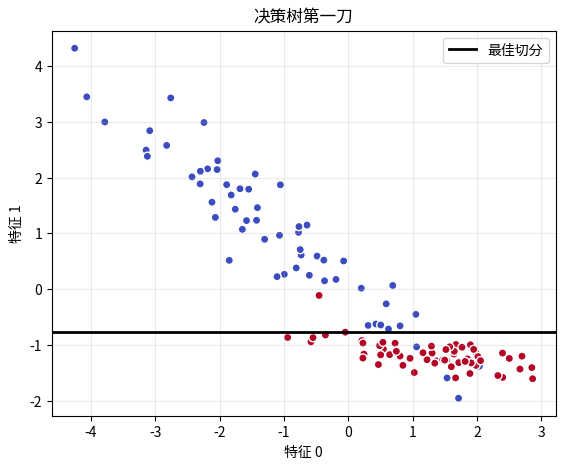

In [5]:
X_demo, y_demo = make_classification(
    n_samples=120,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.2,
    random_state=8,
)


def best_split(X, y):
    n_samples, n_features = X.shape
    best = {"feature": None, "threshold": None, "gini": float("inf")}
    for feature in range(n_features):
        for threshold in np.unique(X[:, feature]):
            left_mask = X[:, feature] <= threshold
            right_mask = ~left_mask
            if left_mask.sum() == 0 or right_mask.sum() == 0:
                continue
            weighted_gini = (
                left_mask.sum() / n_samples * gini_impurity(y[left_mask])
                + right_mask.sum() / n_samples * gini_impurity(y[right_mask])
            )
            if weighted_gini < best["gini"]:
                best = {"feature": feature, "threshold": threshold, "gini": weighted_gini}
    return best


split = best_split(X_demo, y_demo)
print("最佳切分:", split)

plt.figure(figsize=(6.5, 5))
plt.scatter(X_demo[:, 0], X_demo[:, 1], c=y_demo, cmap="coolwarm", s=35, edgecolor="white")
if split["feature"] == 0:
    plt.axvline(split["threshold"], color="black", linewidth=2, label="最佳切分")
else:
    plt.axhline(split["threshold"], color="black", linewidth=2, label="最佳切分")
plt.xlabel("特征 0")
plt.ylabel("特征 1")
plt.title("决策树第一刀")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

## 5. 从零实现一棵决策树

决策树天然适合递归：

- 当前节点足够纯、深度达到上限、样本太少：停止，生成叶节点。
- 否则找到最佳切分，分成左右子节点。
- 对左右子节点重复同样过程。

叶节点的预测值通常是该节点中出现次数最多的类别。

In [6]:
class DecisionTreeNode:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value


class SimpleDecisionTree:
    def __init__(self, max_depth=5, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split

    def fit(self, X, y):
        self.tree = self._build_tree(X, y, depth=0)
        return self

    def _build_tree(self, X, y, depth):
        n_samples = len(y)
        if depth >= self.max_depth or n_samples < self.min_samples_split or len(np.unique(y)) == 1:
            return DecisionTreeNode(value=Counter(y).most_common(1)[0][0])

        split = best_split(X, y)
        if split["feature"] is None:
            return DecisionTreeNode(value=Counter(y).most_common(1)[0][0])

        left_mask = X[:, split["feature"]] <= split["threshold"]
        left_tree = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_tree = self._build_tree(X[~left_mask], y[~left_mask], depth + 1)
        return DecisionTreeNode(split["feature"], split["threshold"], left_tree, right_tree)

    def predict(self, X):
        return np.array([self._predict_one(x, self.tree) for x in X])

    def _predict_one(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature] <= node.threshold:
            return self._predict_one(x, node.left)
        return self._predict_one(x, node.right)


iris = load_iris()
X_iris, y_iris = iris.data, iris.target
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(X_iris, y_iris, test_size=0.3, random_state=42)

tree_model = SimpleDecisionTree(max_depth=4).fit(X_train_i, y_train_i)
y_pred_tree = tree_model.predict(X_test_i)
acc_tree = accuracy_score(y_test_i, y_pred_tree)
print(f"鸢尾花数据集准确率: {acc_tree:.4f}")
assert acc_tree > 0.85
print("验证通过：简单决策树准确率 > 85%")

鸢尾花数据集准确率: 0.9556
验证通过：简单决策树准确率 > 85%


### 递归建树时每一步在做什么

从零实现代码看起来短，但里面包含完整建树逻辑：

1. `_build_tree(X, y, depth)` 表示“给当前这批样本建一棵子树”。
2. 如果满足停止条件，就不再切分，直接返回叶节点。
3. 如果还可以切分，就调用 `best_split` 找当前节点的最佳问题。
4. 用这个问题把样本分成左、右两批。
5. 对左、右两批样本分别调用 `_build_tree`。

递归的关键是：每个子问题和原问题形式一样，只是数据更少、深度更深。

## 6. 树太深为什么会过拟合

决策树如果不限制深度，可以一直切到每个叶节点只剩很少样本，甚至把训练集完全记住。

这会导致：

- 训练准确率很高，甚至 100%。
- 测试准确率没有同步提升，甚至下降。

常见控制复杂度的参数：`max_depth`、`min_samples_split`、`min_samples_leaf`、剪枝。

max_depth  训练准确率        测试准确率        诊断
------------------------------------------------
1          0.7629       0.7333       欠拟合
2          0.7743       0.8333       欠拟合
3          0.8943       0.8200       较合适
5          0.9714       0.8867       较合适
8          0.9857       0.8867       较合适
无限         1.0000       0.8800       过拟合


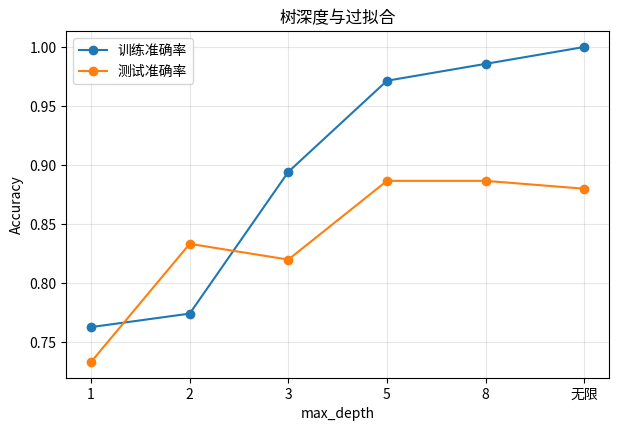

In [7]:
X_complex, y_complex = make_classification(n_samples=500, n_features=10, n_informative=5, n_redundant=2, random_state=42)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_complex, y_complex, test_size=0.3, random_state=42)

depths = [1, 2, 3, 5, 8, None]
train_scores, test_scores = [], []
print(f"{'max_depth':<10} {'训练准确率':<12} {'测试准确率':<12} {'诊断'}")
print("-" * 48)
for depth in depths:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train_c, y_train_c)
    train_acc = clf.score(X_train_c, y_train_c)
    test_acc = clf.score(X_test_c, y_test_c)
    train_scores.append(train_acc)
    test_scores.append(test_acc)
    gap = train_acc - test_acc
    diag = "欠拟合" if train_acc < 0.82 else ("过拟合" if gap > 0.10 else "较合适")
    label = str(depth) if depth is not None else "无限"
    print(f"{label:<10} {train_acc:<12.4f} {test_acc:<12.4f} {diag}")

labels = [str(d) if d is not None else "无限" for d in depths]
plt.figure(figsize=(7, 4.5))
plt.plot(labels, train_scores, marker="o", label="训练准确率")
plt.plot(labels, test_scores, marker="o", label="测试准确率")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("树深度与过拟合")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 7. 随机森林：很多棵不一样的树投票

单棵树的缺点是方差高：数据稍微变一点，树结构可能大变。随机森林用很多棵树投票，让模型更稳定。

随机森林的随机性来自：

1. **Bootstrap 采样**：每棵树从训练集中有放回抽样。
2. **随机特征子集**：每次分裂只考虑一部分特征。

每棵树可能都有偏差，但错误方向不同，投票后可以相互抵消。

In [8]:
class SimpleRandomForest:
    def __init__(self, n_trees=20, max_depth=4, sample_ratio=0.8):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.sample_ratio = sample_ratio
        self.trees = []

    def fit(self, X, y):
        self.trees = []
        n_samples = len(X)
        for _ in range(self.n_trees):
            indices = np.random.choice(n_samples, int(n_samples * self.sample_ratio), replace=True)
            tree = SimpleDecisionTree(max_depth=self.max_depth).fit(X[indices], y[indices])
            self.trees.append(tree)
        return self

    def predict(self, X):
        predictions = np.array([tree.predict(X) for tree in self.trees])
        return np.array([Counter(votes).most_common(1)[0][0] for votes in predictions.T])


np.random.seed(42)
rf = SimpleRandomForest(n_trees=20, max_depth=4).fit(X_train_i, y_train_i)
y_pred_rf = rf.predict(X_test_i)
acc_rf = accuracy_score(y_test_i, y_pred_rf)
print(f"单棵简单决策树准确率: {acc_tree:.4f}")
print(f"简单随机森林准确率:   {acc_rf:.4f}")

单棵简单决策树准确率: 0.9556
简单随机森林准确率:   1.0000


## 8. sklearn 实战：看懂树结构和特征重要性

sklearn 的决策树和随机森林实现更快、更完善。下面展示：

- 一棵浅层树长什么样。
- 随机森林认为哪些特征更重要。

特征重要性可以帮助解释模型，但不要把它当成因果结论；它只说明模型在当前数据和训练方式下依赖哪些特征。

sklearn 决策树准确率: 1.0000
sklearn 随机森林准确率: 1.0000


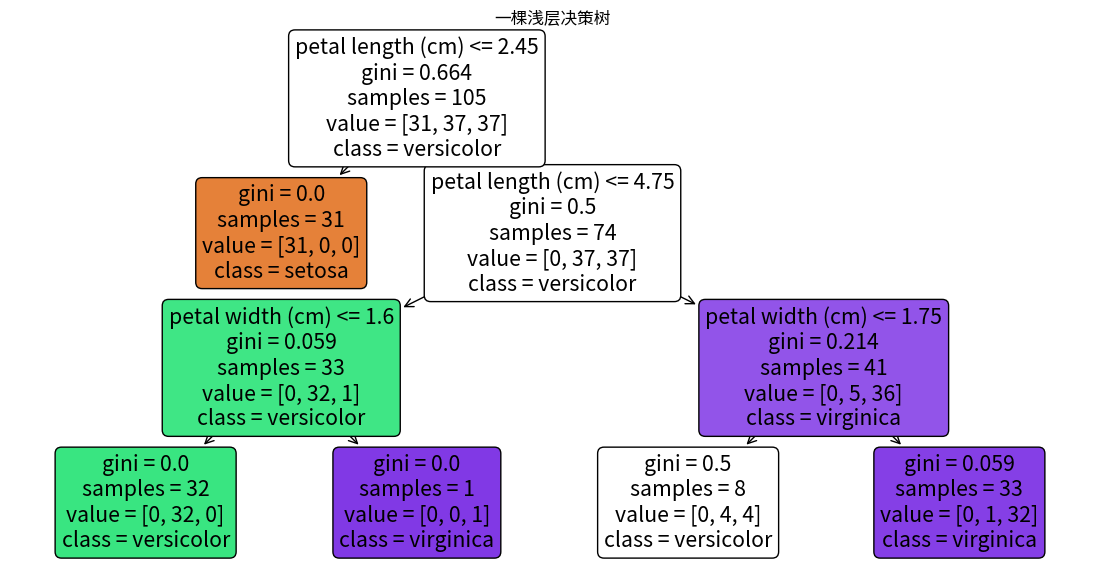

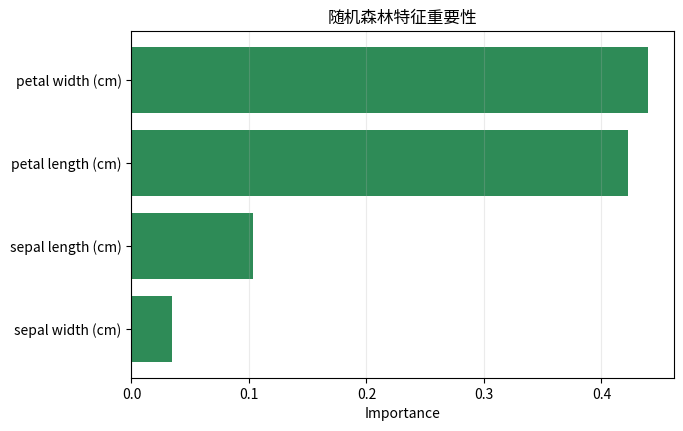

In [9]:
sk_tree = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train_i, y_train_i)
sk_rf = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42).fit(X_train_i, y_train_i)

print(f"sklearn 决策树准确率: {sk_tree.score(X_test_i, y_test_i):.4f}")
print(f"sklearn 随机森林准确率: {sk_rf.score(X_test_i, y_test_i):.4f}")

fig, ax = plt.subplots(figsize=(14, 7))
plot_tree(sk_tree, feature_names=iris.feature_names, class_names=iris.target_names, filled=True, rounded=True, ax=ax)
ax.set_title("一棵浅层决策树")
plt.show()

importances = sk_rf.feature_importances_
order = np.argsort(importances)
plt.figure(figsize=(7, 4.5))
plt.barh(np.array(iris.feature_names)[order], importances[order], color="seagreen")
plt.xlabel("Importance")
plt.title("随机森林特征重要性")
plt.grid(axis="x", alpha=0.25)
plt.show()

## 9. 总结与检查题

| 概念 | 你应该能说出的解释 |
|------|--------------------|
| Gini / Entropy | 节点类别越混杂，不纯度越高 |
| 信息增益 | 切分后不纯度减少多少 |
| 决策树 | 递归学习 if-else 规则 |
| 过拟合 | 树太深会记住训练集噪声 |
| 随机森林 | 多棵随机树投票，降低方差 |

**检查题**：

1. 一个节点里全是同一类样本，Gini 和 Entropy 是多少？
2. 为什么切分后要计算左右子节点的“加权”不纯度？
3. 单棵树训练准确率 100%，测试准确率一般，可能是什么问题？
4. 随机森林为什么比单棵树更稳定？
5. 特征重要性可以解释什么，又不能解释什么？

## 10. 决策树使用建议

### 什么时候优先考虑决策树/随机森林

- 数据是表格数据，而不是图像、语音、长文本。
- 需要较强可解释性，希望能看到规则或特征重要性。
- 特征尺度差异大，不想花太多精力做标准化。
- 想快速建立一个强 baseline。

### 什么时候要小心

- 数据很少但特征很多：树容易过拟合。
- 类别极不平衡：树可能偏向多数类，需要 class weight 或重采样。
- 需要平滑外推：树模型一般不擅长在训练数据范围之外外推。

### 本节最小掌握清单

- 能说出 Gini 和 Entropy 都是在衡量节点混杂程度。
- 能解释信息增益等于“切分前后不纯度减少量”。
- 能理解 `max_depth` 为什么能防止过拟合。
- 能解释随机森林为什么要训练很多棵不同的树。
- 能把特征重要性当成模型解释线索，而不是因果证明。

## 11. 决策树的可解释性应该怎么读

决策树的解释通常沿着一条从根节点到叶节点的路径展开。每经过一个节点，就相当于应用一个条件过滤样本。

例如某条路径可能是：

```text
花瓣长度 > 2.45
花瓣宽度 <= 1.75
预测 versicolor
```

这条路径的含义是：满足这些条件的训练样本中，versicolor 占多数，所以叶节点预测 versicolor。

读树时要注意：

- 越靠近根节点的特征，通常越早参与大范围切分，但不一定代表因果上更重要。
- 某条路径只解释落入该叶节点的一部分样本，不代表全局规律。
- 深树中的规则可能非常细碎，解释性反而下降。

所以浅层树常用于解释，随机森林常用于预测性能。两者目标略有不同。

## 12. 决策树、随机森林和线性模型怎么选

| 情况 | 推荐优先尝试 | 原因 |
|------|--------------|------|
| 特征和目标近似线性关系 | 逻辑回归、线性模型 | 简单、稳定、可解释 |
| 表格数据，有明显阈值规则 | 决策树/随机森林 | 能自动学习 if-else 规则 |
| 非线性关系较多，但数据量中等 | 随机森林、梯度提升树 | 表达能力强，调参成本适中 |
| 图像、语音、文本等复杂非结构化数据 | 神经网络 | 能自动学习复杂表示 |

### 随机森林的优缺点

优点：

- 通常比单棵树稳定。
- 对特征尺度不敏感。
- 可以处理非线性和特征交互。
- 默认参数下往往就是不错的 baseline。

缺点：

- 比单棵树难解释。
- 模型体积更大，预测更慢。
- 对训练数据范围之外的外推能力有限。

学习决策树时最重要的不是记住 API，而是理解“切分让节点更纯”和“复杂度太高会过拟合”这两个核心思想。

## 13. 调参时先动哪些参数

决策树和随机森林参数很多，初学者可以按下面顺序理解：

1. **`max_depth`**：控制树最大深度。越大越复杂，越容易过拟合。
2. **`min_samples_split`**：一个节点至少有多少样本才允许继续切分。越大越保守。
3. **`min_samples_leaf`**：叶节点至少保留多少样本。可以防止出现只服务于极少样本的规则。
4. **`n_estimators`**：随机森林中树的数量。更多树通常更稳定，但计算更慢。
5. **`max_features`**：每次切分考虑多少特征。较小值会增加树之间差异，有助于降低方差。

一个稳妥策略：先用随机森林默认参数建立 baseline，再通过交叉验证调 `max_depth`、`min_samples_leaf` 和 `n_estimators`。